In [2]:
import os
import re
import gc
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet"]:
    nltk.download(pkg, quiet=True)

import spacy
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH   = "../data/processed/sample_complaints.csv"
OUT_DATA    = "../data/processed/processed_data.csv"
OUT_TFIDF   = "../models/tfidf_vectorizer.pkl"
OUT_FIG_DIR = "../outputs/figures"

for d in ["../models", OUT_FIG_DIR]:
    os.makedirs(d, exist_ok=True)

DOMAIN_STOP = {
    "company", "account", "consumer", "bank", "told", "would",
    "said", "called", "also", "get", "got", "one", "us", "go",
}
STOP_WORDS = set(stopwords.words("english")) | DOMAIN_STOP

print(f"Setup complete  |  stopwords: {len(STOP_WORDS)}  |  domain additions: {len(DOMAIN_STOP)}")

Setup complete  |  stopwords: 212  |  domain additions: 14


In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
for col in df.columns:
    print(f"  {col:<30s}  {str(df[col].dtype):<10}  {df[col].notna().sum():,} non-null")

print(f"\nSample narrative (first 300 chars):")
print(f"  {df['narrative'].iloc[0][:300]}...")

Shape: 20,000 rows x 6 columns
  narrative                       str         20,000 non-null
  product                         str         20,000 non-null
  product_raw                     str         20,000 non-null
  issue                           str         20,000 non-null
  company_response                str         20,000 non-null
  word_count                      int64       20,000 non-null

Sample narrative (first 300 chars):
  I want to stress that I did not give written permission for these specific transactions to be included in my consumer report. At no point did I authorize these entries, and their presence on my report is unwarranted. Consequently, I am formally requesting that these accounts be blocked and removed f...


In [4]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    text = re.sub(r"x{2,}", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["narrative"].apply(clean_text)

df["raw_wc"]   = df["narrative"].str.split().str.len()
df["clean_wc"] = df["text_clean"].str.split().str.len()

empty = (df["clean_wc"] == 0).sum()
print(f"Cleaning complete  |  empty after clean: {empty}")
print(f"  Mean words   - raw: {df['raw_wc'].mean():.1f}  ->  clean: {df['clean_wc'].mean():.1f}")
print(f"  Median words - raw: {df['raw_wc'].median():.0f}  ->  clean: {df['clean_wc'].median():.0f}")

if empty:
    df = df[df["clean_wc"] > 0].reset_index(drop=True)
    print(f"  Dropped {empty} empty rows  |  remaining: {len(df):,}")

Cleaning complete  |  empty after clean: 3
  Mean words   - raw: 122.5  ->  clean: 110.9
  Median words - raw: 108  ->  clean: 96
  Dropped 3 empty rows  |  remaining: 19,997


In [5]:
def lemmatize_batch(texts, nlp, stop_words, batch_size=512):
    result = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = [
            t.lemma_ for t in doc
            if t.lemma_ not in stop_words
            and len(t.lemma_) > 2
            and t.lemma_.isalpha()
        ]
        result.append(" ".join(tokens))
    return result

print(f"Lemmatizing {len(df):,} texts ...")
df["text_processed"] = lemmatize_batch(df["text_clean"].tolist(), nlp, STOP_WORDS)

df["proc_wc"] = df["text_processed"].str.split().str.len()
empty_proc = (df["proc_wc"] == 0).sum()

reduction = (1 - df["proc_wc"].median() / df["clean_wc"].median()) * 100
print(f"Done  |  empty after lemmatize: {empty_proc}")
print(
    f"  Median words  clean: {df['clean_wc'].median():.0f}  ->  "
    f"processed: {df['proc_wc'].median():.0f}  (reduction: {reduction:.1f}%)"
)

if empty_proc:
    df = df[df["proc_wc"] > 0].reset_index(drop=True)

Lemmatizing 19,997 texts ...
Done  |  empty after lemmatize: 0
  Median words  clean: 96  ->  processed: 44  (reduction: 54.2%)



Sentiment distribution:
  negative    10,308  (51.5%)
  neutral        790  (4.0%)
  positive     8,899  (44.5%)


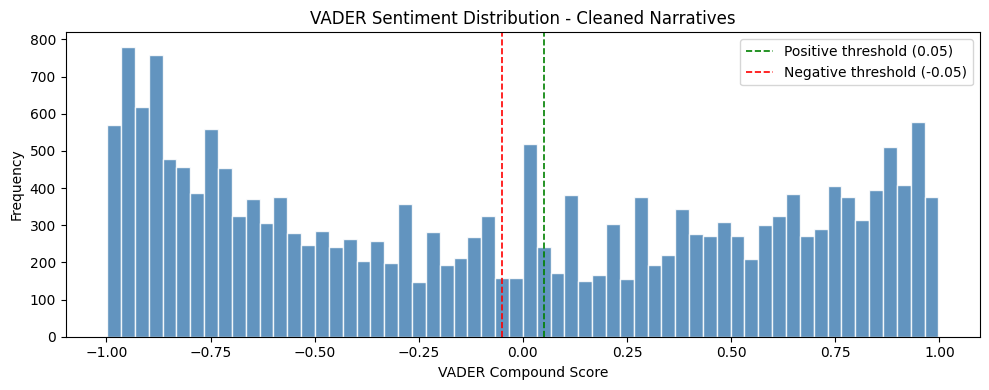

In [6]:
vader = SentimentIntensityAnalyzer()

df["compound"]  = df["text_clean"].apply(lambda x: vader.polarity_scores(x)["compound"])
df["sentiment"] = df["compound"].apply(
    lambda c: "positive" if c >= 0.05 else ("negative" if c <= -0.05 else "neutral")
)

counts = df["sentiment"].value_counts()
print(f"\nSentiment distribution:")
for label in ["negative", "neutral", "positive"]:
    c = counts.get(label, 0)
    print(f"  {label:<10}  {c:>6,}  ({c/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["compound"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline( 0.05, color="green", linestyle="--", lw=1.2, label="Positive threshold (0.05)")
ax.axvline(-0.05, color="red",   linestyle="--", lw=1.2, label="Negative threshold (-0.05)")
ax.set(
    xlabel="VADER Compound Score",
    ylabel="Frequency",
    title="VADER Sentiment Distribution - Cleaned Narratives",
)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_FIG_DIR}/03_vader_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
tfidf = TfidfVectorizer(
    max_features=20_000,
    min_df=5,
    max_df=0.90,
    ngram_range=(1, 2),
    sublinear_tf=True,
)
tfidf.fit(df["text_processed"])

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}")
joblib.dump(tfidf, OUT_TFIDF)
print(f"Saved: {OUT_TFIDF}")

TF-IDF vocabulary size: 20,000
Saved: ../models/tfidf_vectorizer.pkl


In [8]:
KEEP_COLS = [
    "narrative",
    "product", "product_raw",
    "issue", "company_response",
    "word_count", "text_clean", "text_processed",
    "compound", "sentiment",
]

df[KEEP_COLS].to_csv(OUT_DATA, index=False)

print(f"Saved: {OUT_DATA}  ({len(df):,} rows x {len(KEEP_COLS)} columns)")
print(f"  File size: {os.path.getsize(OUT_DATA) / 1e6:.1f} MB")

Saved: ../data/processed/processed_data.csv  (19,997 rows x 10 columns)
  File size: 36.4 MB
